# Dashboard RH — Analyse des employés
### Notebook 1 : Nettoyage, KPI et analyse exploratoire

**Projet BI portfolio — People Analytics**
Dataset : `HRDataset_v14.csv` (Kaggle — *rhuebner/human-resources-data-set*), 311 employés.

## Objectifs
1. Identifier les **causes du turnover (attrition)**
2. Analyser les **facteurs d'absentéisme**
3. Mesurer la **satisfaction** et la **performance** des employés
4. Détecter les **profils à risque de départ**
5. Proposer des **leviers de rétention**

> **Note méthodologique** — Les colonnes attendues dans le brief (WorkLifeBalance, DistanceFromHome,
> OverTime, Education) appartiennent au dataset *IBM HR Analytics*. Le dataset réel utilisé ici
> (rhuebner) fournit des équivalents : `Termd`/`TermReason` (attrition), `Salary`, `EmpSatisfaction`,
> `EngagementSurvey`, `PerformanceScore`, `Absences`. `SpecialProjectsCount` sert de proxy d'implication
> (à défaut d'OverTime).

## 1. Chargement & première exploration

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = {"No": "#2E86AB", "Yes": "#E4572E"}
ANALYSIS_DATE = pd.Timestamp("2019-12-31")  # fin de la période couverte par les données

DATA = Path("..") / "data" / "HRDataset_v14.csv"
df = pd.read_csv(DATA, encoding="utf-8-sig")   # utf-8-sig : le fichier a un BOM
df.columns = [c.strip() for c in df.columns]
print("Dimensions :", df.shape)
df.head(3)

Dimensions : (311, 36)


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3


In [2]:
# Types, valeurs manquantes, doublons
display(df.dtypes.to_frame("dtype").T)
print("Valeurs manquantes :")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nDoublons (EmpID) :", df['EmpID'].duplicated().sum())
print("Doublons (lignes) :", df.duplicated().sum())

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
dtype,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,...,object,float64,object,object,float64,int64,int64,object,int64,int64


Valeurs manquantes :
DateofTermination    207
ManagerID              8
dtype: int64

Doublons (EmpID) : 0
Doublons (lignes) : 0


**Constats :**
- `DateofTermination` : 207 valeurs manquantes = employés **toujours actifs** (normal, on les conserve).
- `ManagerID` : 8 manquants → on impute `-1` (manager inconnu).
- Aucun doublon.
- `DOB`, `DateofHire`, `DateofTermination` sont des **chaînes** → à convertir.
- `HispanicLatino` contient `No/Yes/no/yes` → **casse à uniformiser**.

## 2. Nettoyage des données

In [3]:
# 2.1 Doublons
df = df.drop_duplicates().drop_duplicates(subset=["EmpID"], keep="first")

# 2.2 Trim des chaînes
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan})

# 2.3 Uniformisation des catégories
df["HispanicLatino"] = df["HispanicLatino"].str.capitalize()      # no -> No
df["Sex"] = df["Sex"].str.upper()
df["GenderLabel"] = df["Sex"].map({"M": "Homme", "F": "Femme"})
print("HispanicLatino après nettoyage :", df["HispanicLatino"].unique())

HispanicLatino après nettoyage : ['No' 'Yes']


In [4]:
# 2.4 Dates — DOB est en m/d/yy : bug du siècle (ex. '07/10/83' -> 2083 au lieu de 1983)
dob = pd.to_datetime(df["DOB"], format="%m/%d/%y", errors="coerce")
future = dob > ANALYSIS_DATE
print("Dates de naissance mal interprétées (futures) à corriger :", future.sum())
dob.loc[future] = dob.loc[future] - pd.offsets.DateOffset(years=100)
df["DOB"] = dob
for c in ["DateofHire", "DateofTermination", "LastPerformanceReview_Date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# 2.5 Imputation ManagerID
df["ManagerID"] = df["ManagerID"].fillna(-1).astype(int)
print("Année de naissance min/max après correction :", int(df['DOB'].dt.year.min()), int(df['DOB'].dt.year.max()))

Dates de naissance mal interprétées (futures) à corriger : 42
Année de naissance min/max après correction : 1951 1992


## 3. Variables dérivées (feature engineering)

In [5]:
# Cible : attrition
df["Attrition"] = np.where(df["Termd"] == 1, "Yes", "No")
df["AttritionFlag"] = df["Termd"].astype(int)
df["IsVoluntary"] = (df["EmploymentStatus"] == "Voluntarily Terminated").astype(int)

# Âge & ancienneté
df["Age"] = ((ANALYSIS_DATE - df["DOB"]).dt.days / 365.25).round().astype("Int64")
end = df["DateofTermination"].fillna(ANALYSIS_DATE)   # actif -> aujourd'hui ; parti -> date de départ
df["TenureYears"] = ((end - df["DateofHire"]).dt.days / 365.25).round(2)

# Revenu & absentéisme
df["MonthlyIncome"] = (df["Salary"] / 12).round().astype(int)
df["AbsenteeismRate"] = (df["Absences"] / 261 * 100).round(2)   # proxy sur 261 jours ouvrés

# Tranches
df["AgeBand"] = pd.cut(df["Age"].astype(float), [0,29,39,49,200], labels=["<30","30-39","40-49","50+"])
df["TenureBand"] = pd.cut(df["TenureYears"], [-.1,2,5,8,100], labels=["0-2 ans","3-5 ans","6-8 ans","9+ ans"])
df["SalaryBand"] = pd.cut(df["Salary"], [0,55000,70000,90000,1e9], labels=["<55k","55-70k","70-90k","90k+"])
df["HighPerformer"] = df["PerformanceScore"].isin(["Exceeds"]).astype(int)
df["LowPerformer"]  = df["PerformanceScore"].isin(["PIP","Needs Improvement"]).astype(int)
df[["Age","TenureYears","AgeBand","TenureBand","Attrition"]].head()

,Age,TenureYears,AgeBand,TenureBand,Attrition
0,36,8.49,30-39,9+ ans,No
1,45,1.22,40-49,0-2 ans,Yes
2,31,1.22,30-39,0-2 ans,Yes
3,31,11.98,30-39,9+ ans,No
4,30,5.16,30-39,6-8 ans,Yes


### Détection des valeurs aberrantes (IQR)

In [6]:
q1,q3 = df["Salary"].quantile([.25,.75]); iqr=q3-q1; hi=q3+1.5*iqr
print(f"Seuil haut salaire (IQR) : {hi:,.0f} $  ->  {(df['Salary']>hi).sum()} employés au-dessus")
print("Postes concernés :", df.loc[df['Salary']>hi,'Position'].unique()[:6])
print("Ages hors [18-75] :", ((df['Age']<18)|(df['Age']>75)).sum())
print("Anciennetés négatives :", (df['TenureYears']<0).sum())
print("-> Les 'outliers' salaire sont des postes de direction légitimes : on les conserve.")

Seuil haut salaire (IQR) : 96,838 $  ->  29 employés au-dessus
Postes concernés : ['Sr. DBA' 'Database Administrator' 'Enterprise Architect'
 'Sr. Accountant' 'BI Director' 'Director of Operations']
Ages hors [18-75] : 0
Anciennetés négatives : 0
-> Les 'outliers' salaire sont des postes de direction légitimes : on les conserve.


## 4. KPI RH

In [7]:
kpis = {
 "Effectif total": len(df),
 "Effectif actif": int((df.Termd==0).sum()),
 "Départs": int((df.Termd==1).sum()),
 "Taux d'attrition (%)": round(df.AttritionFlag.mean()*100,1),
 "Attrition volontaire (%)": round(df.IsVoluntary.mean()*100,1),
 "Taux d'absentéisme (%)": round(df.AbsenteeismRate.mean(),2),
 "Satisfaction moyenne /5": round(df.EmpSatisfaction.mean(),2),
 "Engagement moyen /5": round(df.EngagementSurvey.mean(),2),
 "% hauts performeurs": round(df.HighPerformer.mean()*100,1),
 "Ancienneté moyenne (ans)": round(df.TenureYears.mean(),1),
 "Salaire annuel moyen ($)": int(df.Salary.mean()),
 "Âge moyen": round(df.Age.astype(float).mean(),1),
}
pd.DataFrame(kpis.items(), columns=["KPI","Valeur"])

,KPI,Valeur
0,Effectif total,311.00
1,Effectif actif,207.00
2,Départs,104.00
3,Taux d'attrition (%),33.40
4,Attrition volontaire (%),28.30
5,Taux d'absentéisme (%),3.92
6,Satisfaction moyenne /5,3.89
7,Engagement moyen /5,4.11
8,% hauts performeurs,11.90
9,Ancienneté moyenne (ans),5.40


## 5. Analyse exploratoire — Causes de l'attrition

### 5.1 Attrition globale

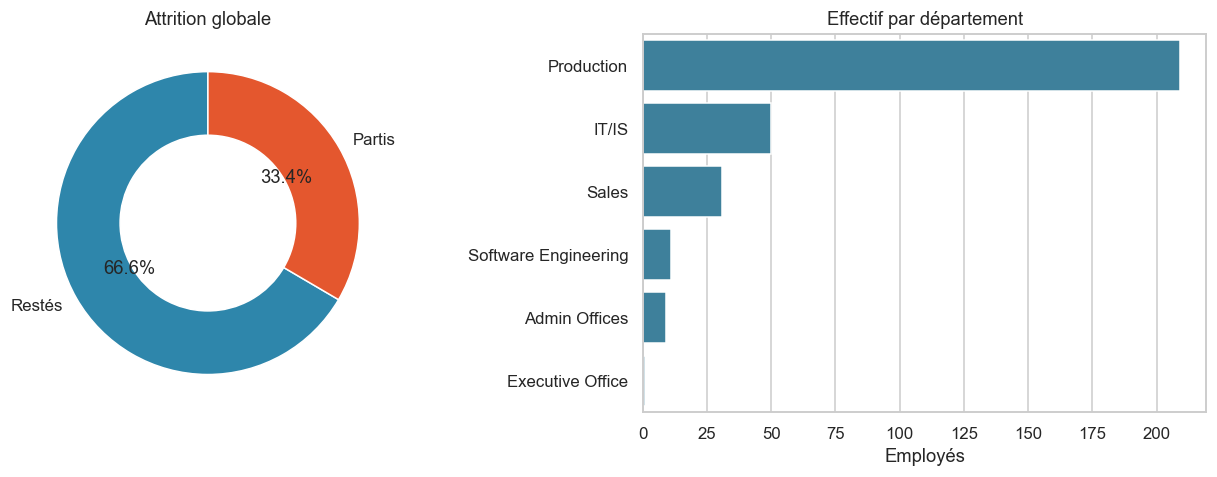

In [8]:
fig,ax = plt.subplots(1,2,figsize=(12,4.5))
c = df["Attrition"].value_counts()
ax[0].pie(c, labels=["Restés","Partis"], autopct="%1.1f%%", colors=["#2E86AB","#E4572E"],
          startangle=90, wedgeprops=dict(width=.42, edgecolor="white"))
ax[0].set_title("Attrition globale")
order = df["Department"].value_counts().index
sns.countplot(data=df, y="Department", order=order, color="#2E86AB", ax=ax[1])
ax[1].set_title("Effectif par département"); ax[1].set_xlabel("Employés"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

### 5.2 Attrition par département, âge et ancienneté

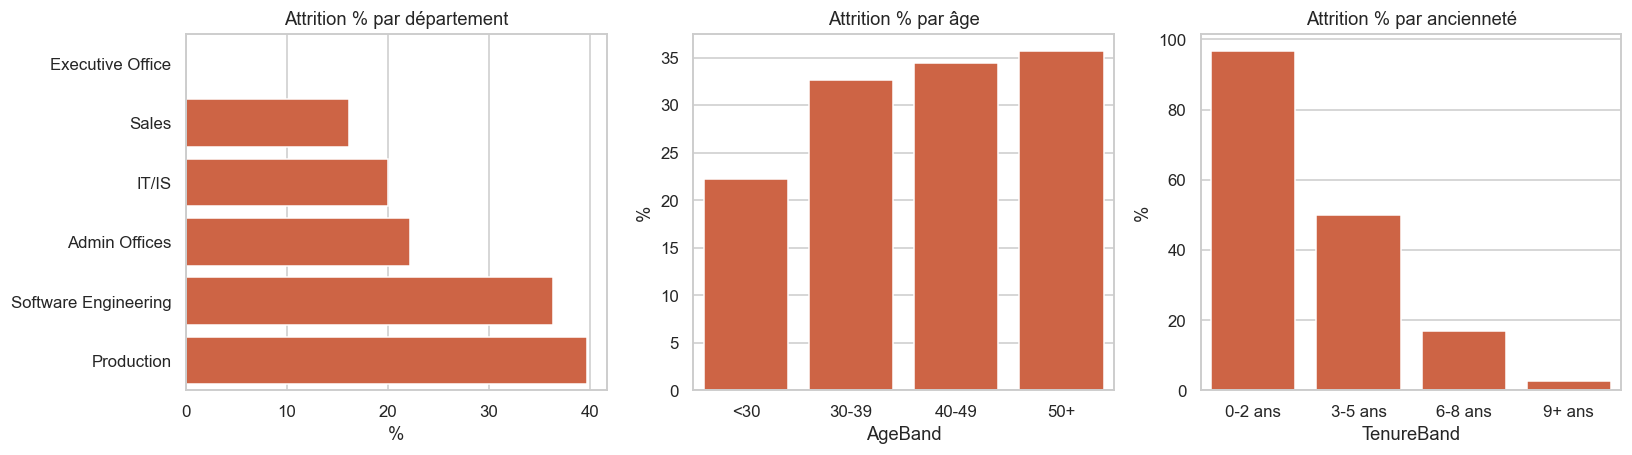

In [9]:
def rate_by(col, order=None):
    g = df.groupby(col, observed=True)["AttritionFlag"].mean().mul(100)
    return (g.reindex(order) if order else g).dropna()

fig,ax = plt.subplots(1,3,figsize=(15,4.3))
g = rate_by("Department").sort_values()
sns.barplot(x=g.values, y=g.index, color="#E4572E", ax=ax[0]); ax[0].set_title("Attrition % par département"); ax[0].set_xlabel("%"); ax[0].set_ylabel("")
g = rate_by("AgeBand", ["<30","30-39","40-49","50+"])
sns.barplot(x=g.index, y=g.values, color="#E4572E", ax=ax[1]); ax[1].set_title("Attrition % par âge"); ax[1].set_ylabel("%")
g = rate_by("TenureBand", ["0-2 ans","3-5 ans","6-8 ans","9+ ans"])
sns.barplot(x=g.index, y=g.values, color="#E4572E", ax=ax[2]); ax[2].set_title("Attrition % par ancienneté"); ax[2].set_ylabel("%")
plt.tight_layout(); plt.show()

> **Lecture** — L'**ancienneté** est le signal le plus puissant : ~97 % des départs concernent les
> employés de **0-2 ans**, contre 2,6 % au-delà de 9 ans. La **Production** est le département le plus
> touché. *(Attention : la relation ancienneté↔attrition est en partie mécanique — un employé parti
> cesse d'accumuler de l'ancienneté ; on l'interprète comme « les départs surviennent tôt ».)*

### 5.3 Satisfaction, engagement et salaire

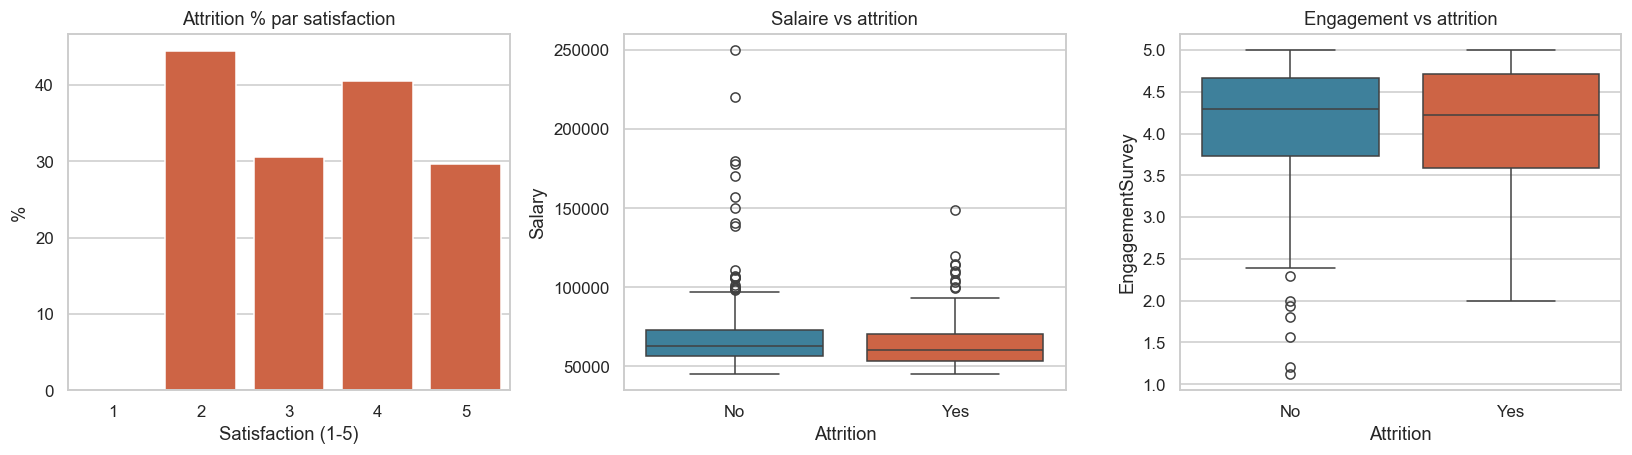

Salaire moyen — restés vs partis : {'No': 70694.0, 'Yes': 65690.0}
Satisfaction moyenne — restés vs partis : {'No': 3.89, 'Yes': 3.88}


In [10]:
fig,ax = plt.subplots(1,3,figsize=(15,4.3))
g = rate_by("EmpSatisfaction").sort_index()
sns.barplot(x=g.index.astype(int), y=g.values, color="#E4572E", ax=ax[0])
ax[0].set_title("Attrition % par satisfaction"); ax[0].set_xlabel("Satisfaction (1-5)"); ax[0].set_ylabel("%")
sns.boxplot(data=df, x="Attrition", y="Salary", hue="Attrition", palette=PALETTE, legend=False, ax=ax[1])
ax[1].set_title("Salaire vs attrition")
sns.boxplot(data=df, x="Attrition", y="EngagementSurvey", hue="Attrition", palette=PALETTE, legend=False, ax=ax[2])
ax[2].set_title("Engagement vs attrition")
plt.tight_layout(); plt.show()
print("Salaire moyen — restés vs partis :", df.groupby('Attrition').Salary.mean().round().to_dict())
print("Satisfaction moyenne — restés vs partis :", df.groupby('Attrition').EmpSatisfaction.mean().round(2).to_dict())

> **Finding contre-intuitif** — Dans ce dataset, la **satisfaction déclarée et l'engagement ne
> discriminent quasiment pas** les partants (satisfaction moyenne 3,89 vs 3,88). L'écart de salaire est
> modéré (~5 000 $). Les vrais leviers sont ailleurs : **source de recrutement, manager, ancienneté**.

### 5.4 Source de recrutement & manager — les vrais prédicteurs

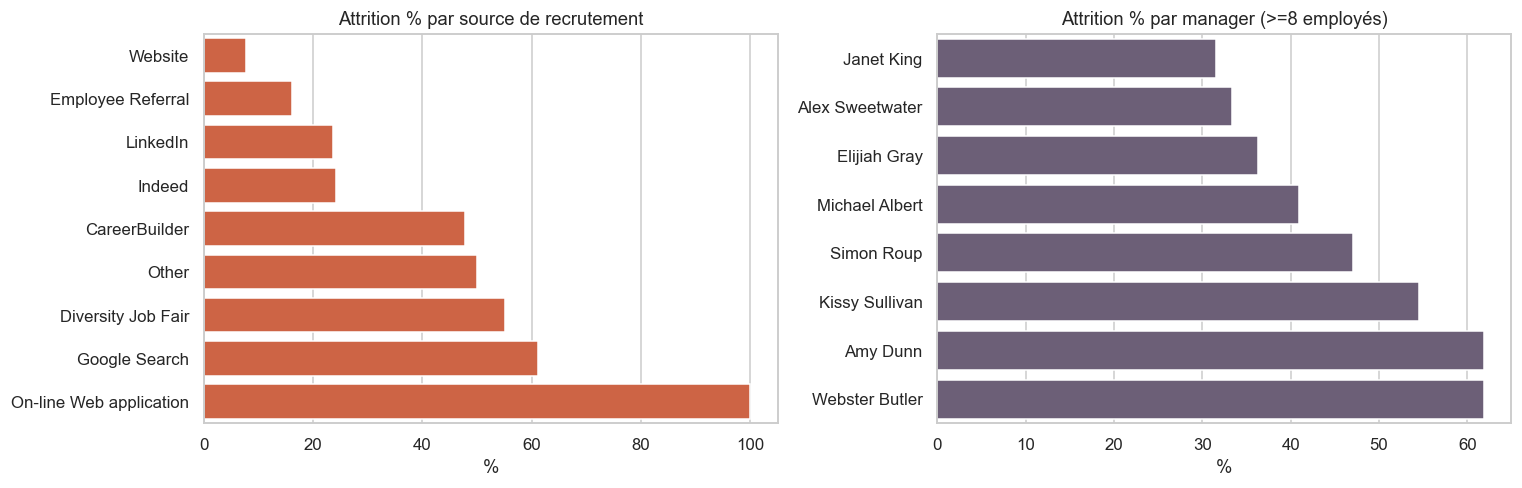

In [11]:
fig,ax = plt.subplots(1,2,figsize=(14,4.6))
g = rate_by("RecruitmentSource").sort_values()
sns.barplot(x=g.values, y=g.index, color="#E4572E", ax=ax[0])
ax[0].set_title("Attrition % par source de recrutement"); ax[0].set_xlabel("%"); ax[0].set_ylabel("")
m = df.groupby("ManagerName")["AttritionFlag"].agg(["mean","count"]); m = m[m["count"]>=8]
m["mean"] *= 100; m = m.sort_values("mean").tail(8)
sns.barplot(x=m["mean"].values, y=m.index, color="#6C5B7B", ax=ax[1])
ax[1].set_title("Attrition % par manager (>=8 employés)"); ax[1].set_xlabel("%"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

### 5.5 Absentéisme & performance

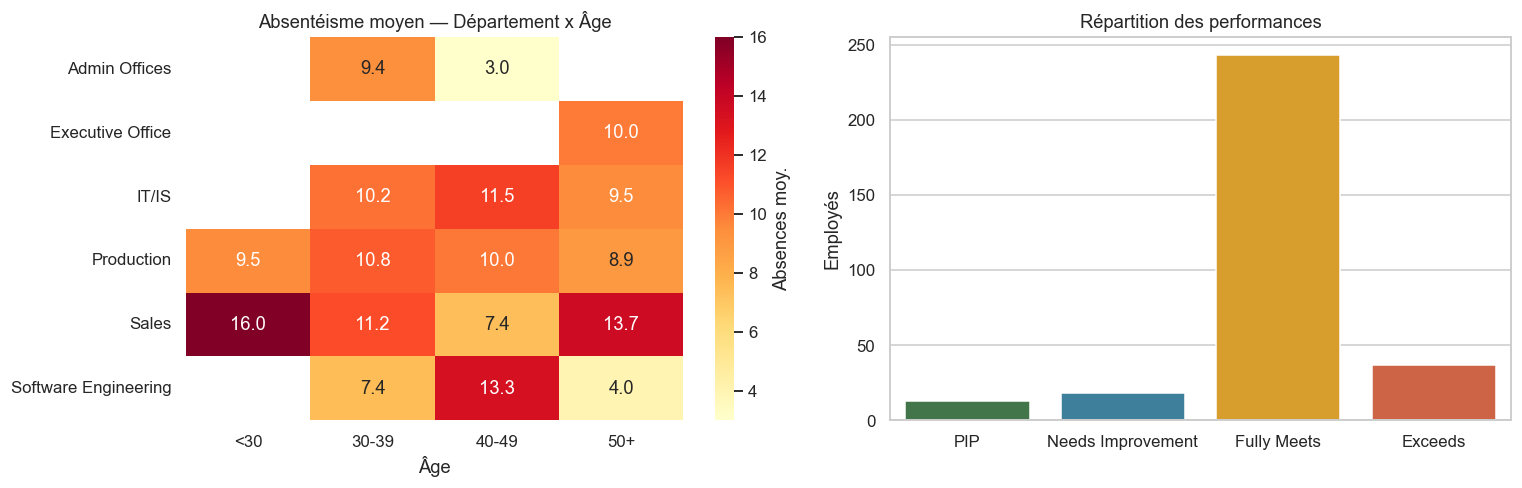

In [12]:
fig,ax = plt.subplots(1,2,figsize=(14,4.6))
pivot = df.pivot_table(index="Department", columns="AgeBand", values="Absences", aggfunc="mean", observed=True)
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax[0], cbar_kws={"label":"Absences moy."})
ax[0].set_title("Absentéisme moyen — Département x Âge"); ax[0].set_xlabel("Âge"); ax[0].set_ylabel("")
sns.countplot(data=df, x="PerformanceScore", order=["PIP","Needs Improvement","Fully Meets","Exceeds"],
              hue="PerformanceScore", palette=["#E4572E","#F3A712","#2E86AB","#3A7D44"], legend=False, ax=ax[1])
ax[1].set_title("Répartition des performances"); ax[1].set_xlabel(""); ax[1].set_ylabel("Employés")
plt.tight_layout(); plt.show()

## 6. Synthèse des profils à risque

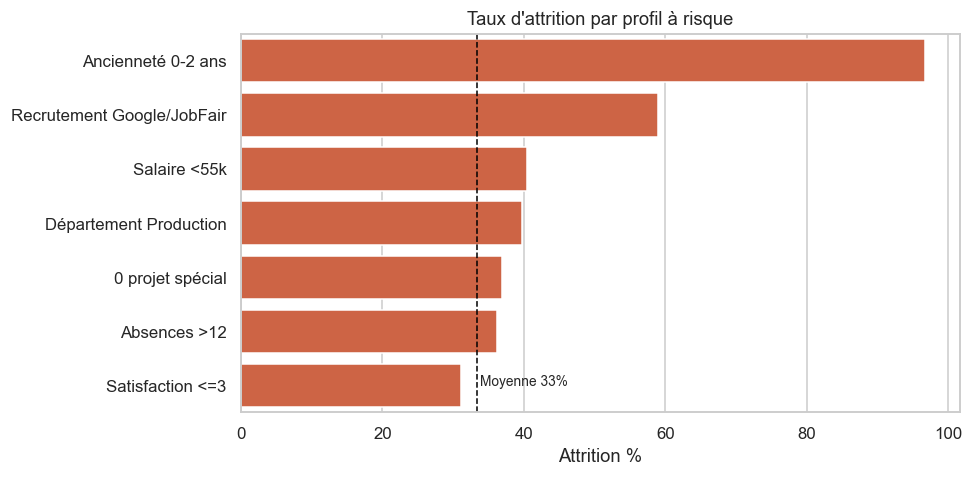

,Profil,Attrition %,Effectif
3,Ancienneté 0-2 ans,96.8,31
5,Recrutement Google/JobFair,59.0,78
2,Salaire <55k,40.5,74
6,Département Production,39.7,209
1,0 projet spécial,36.9,241
4,Absences >12,36.2,130
0,Satisfaction <=3,31.1,119


In [13]:
base = df.AttritionFlag.mean()*100
factors = {
 "Satisfaction <=3": df.EmpSatisfaction<=3,
 "0 projet spécial": df.SpecialProjectsCount==0,
 "Salaire <55k": df.Salary<55000,
 "Ancienneté 0-2 ans": df.TenureBand=="0-2 ans",
 "Absences >12": df.Absences>12,
 "Recrutement Google/JobFair": df.RecruitmentSource.isin(["Google Search","Diversity Job Fair"]),
 "Département Production": df.Department=="Production",
}
rows=[(n, round(df.loc[m,"AttritionFlag"].mean()*100,1), int(m.sum())) for n,m in factors.items()]
risk = pd.DataFrame(rows, columns=["Profil","Attrition %","Effectif"]).sort_values("Attrition %",ascending=False)
plt.figure(figsize=(9,4.5))
sns.barplot(data=risk, x="Attrition %", y="Profil", color="#E4572E")
plt.axvline(base, color="black", ls="--", lw=1); plt.text(base+.4, 6, f"Moyenne {base:.0f}%", fontsize=9)
plt.title("Taux d'attrition par profil à risque"); plt.ylabel(""); plt.tight_layout(); plt.show()
risk

## 7. Conclusions & recommandations

**Pourquoi les employés partent-ils ?**
- Les départs sont **précoces** : ils surviennent surtout durant les **2 premières années**.
- Forte concentration en **Production** (39,7 %) et chez certains **managers** (jusqu'à 62 %).
- Certaines **sources de recrutement** (Google Search 61 %, Diversity Job Fair 55 %) produisent des
  recrues beaucoup moins stables que **Website (8 %)** ou **Employee Referral (16 %)**.
- L'**implication dans des projets spéciaux** réduit nettement l'attrition (21 % vs 37 % sans projet).

**Recommandations RH**
1. **Onboarding renforcé 0-24 mois** (parrainage, points réguliers) — là où se concentre le risque.
2. **Rééquilibrer le sourcing** vers les canaux performants (référral, site carrière), auditer Google/Job Fair.
3. **Accompagner les managers** à forte attrition (Production) : formation, suivi, allègement de charge.
4. **Impliquer dans des projets transverses** pour augmenter l'engagement.
5. **Plans de carrière & mobilité** pour les profils techniques (Software Engineering).

➡️ Voir le dashboard Power BI et le rapport `reports/HR_Analytics_Report.md` pour le détail.

## 8. Export des données propres

In [14]:
out = Path("..")/"data"/"processed"/"hr_clean.csv"
cols = ["EmpID","Employee_Name","GenderLabel","Sex","MaritalDesc","Age","AgeBand","RaceDesc",
 "HispanicLatino","CitizenDesc","State","Department","Position","ManagerName","RecruitmentSource",
 "Salary","MonthlyIncome","SalaryBand","DateofHire","DateofTermination","TenureYears","TenureBand",
 "EmploymentStatus","TermReason","Attrition","AttritionFlag","IsVoluntary","EmpSatisfaction",
 "EngagementSurvey","PerformanceScore","PerfScoreID","HighPerformer","LowPerformer",
 "SpecialProjectsCount","DaysLateLast30","Absences","AbsenteeismRate","LastPerformanceReview_Date"]
df[cols].to_csv(out, index=False, encoding="utf-8-sig")
print("Exporté :", out, "->", df[cols].shape)

Exporté : ..\data\processed\hr_clean.csv -> (311, 38)
